In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/fedesoriano/the-boston-houseprice-data/boston.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/kaggle/input/datasets/fedesoriano/the-boston-houseprice-data/boston.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [4]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [6]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

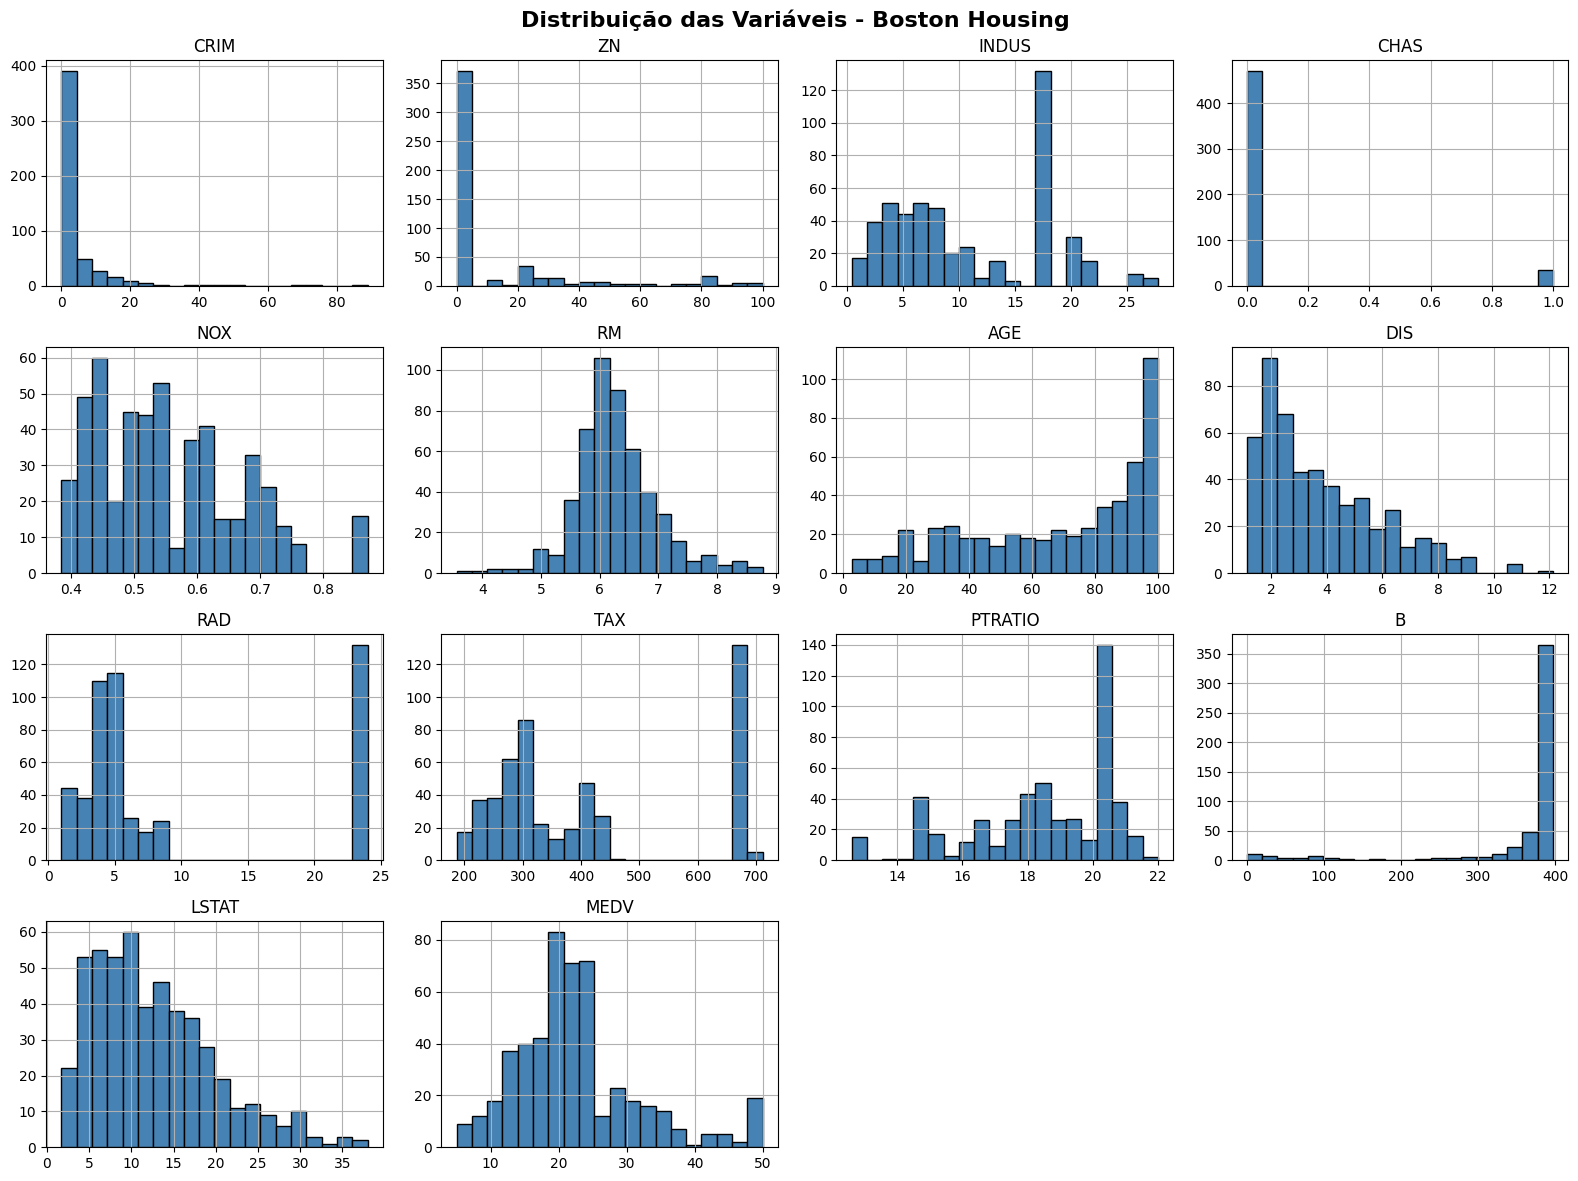

In [8]:
#HISTOGRAMAS
df.hist(figsize=(16, 12), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Distribuição das Variáveis - Boston Housing', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('histogramas.png')
plt.show()

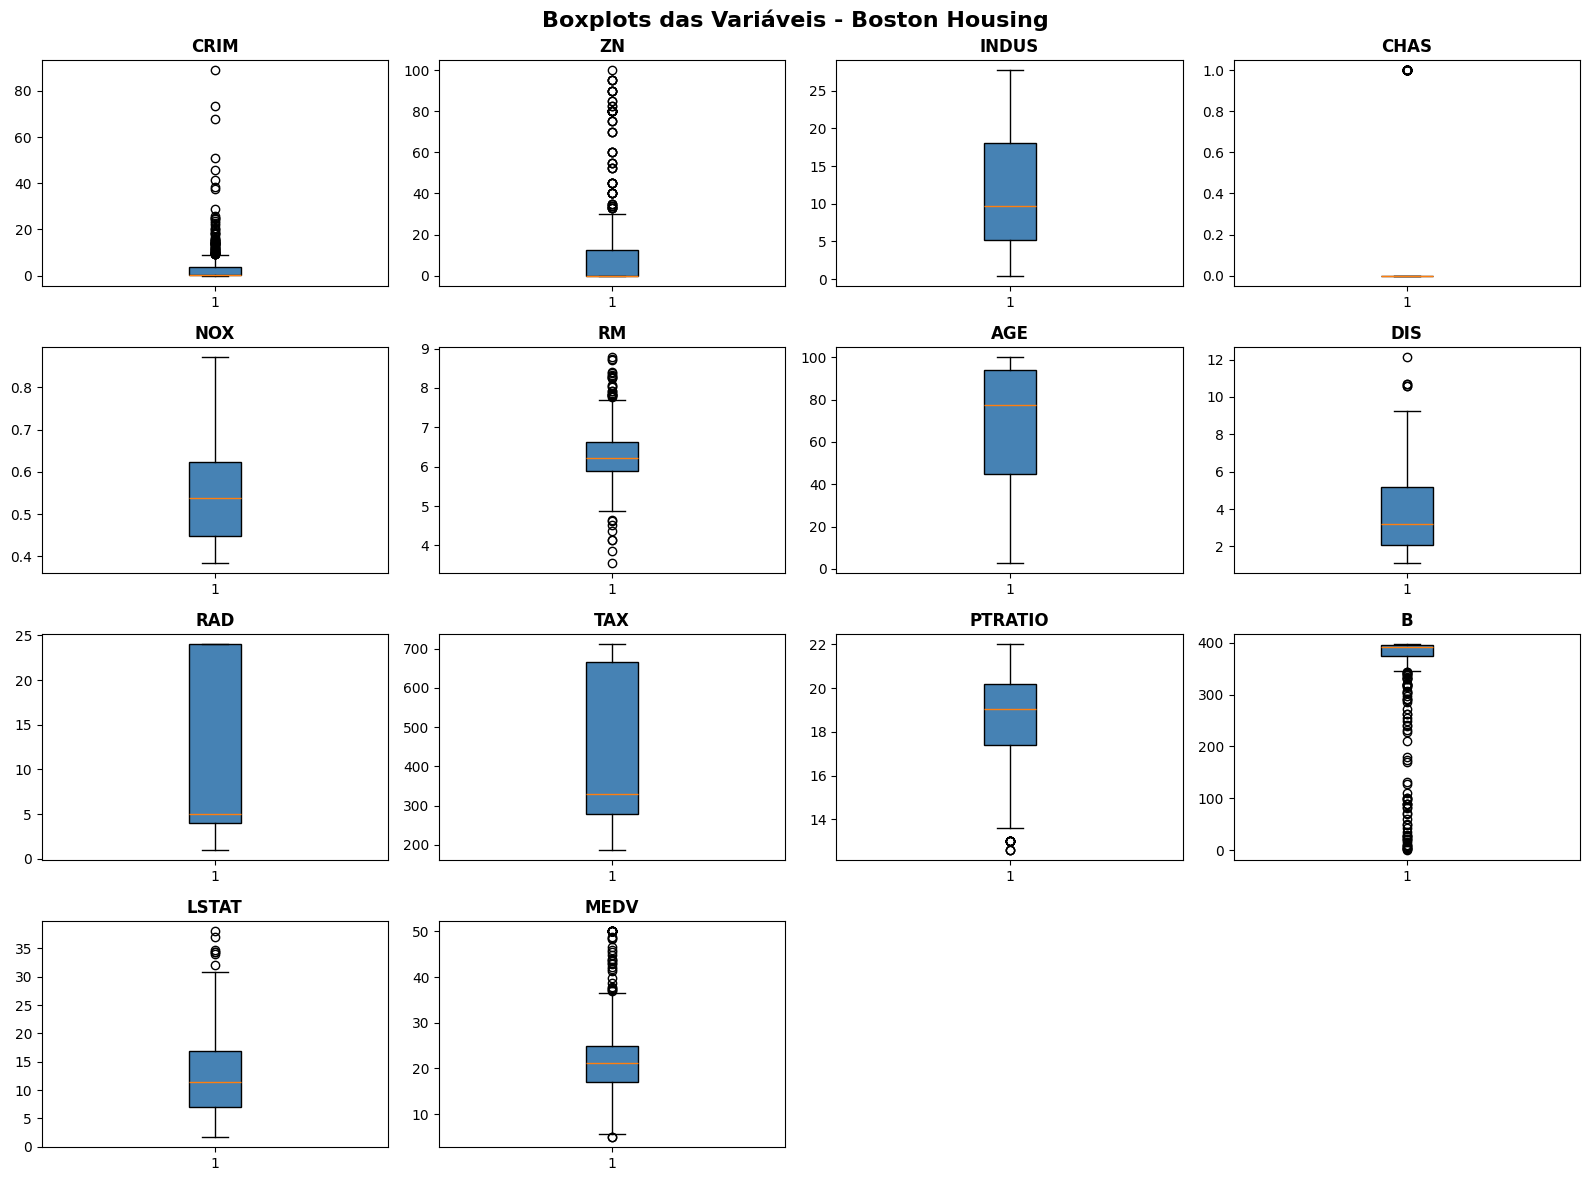

In [9]:
# BOXPLOTS
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(df.columns):
    axes[i].boxplot(df[var], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='black'))
    axes[i].set_title(var, fontweight='bold')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots das Variáveis - Boston Housing', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png')
plt.show()

In [10]:
import pandas as pd

# Supondo que df contém apenas variáveis numéricas float
numericas = df.columns  # todas as colunas já são numéricas

for col in numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inferior = Q1 - 1.5 * IQR
    lim_superior = Q3 + 1.5 * IQR
    
    # Criar coluna booleana para indicar outliers
    df[f'is_outlier_{col}'] = (df[col] < lim_inferior) | (df[col] > lim_superior)

# Verificar quantos outliers cada coluna tem
for col in numericas:
    print(f"{col} - Número de outliers: {df[f'is_outlier_{col}'].sum()}")

CRIM - Número de outliers: 66
ZN - Número de outliers: 68
INDUS - Número de outliers: 0
CHAS - Número de outliers: 35
NOX - Número de outliers: 0
RM - Número de outliers: 30
AGE - Número de outliers: 0
DIS - Número de outliers: 5
RAD - Número de outliers: 0
TAX - Número de outliers: 0
PTRATIO - Número de outliers: 15
B - Número de outliers: 77
LSTAT - Número de outliers: 7
MEDV - Número de outliers: 40


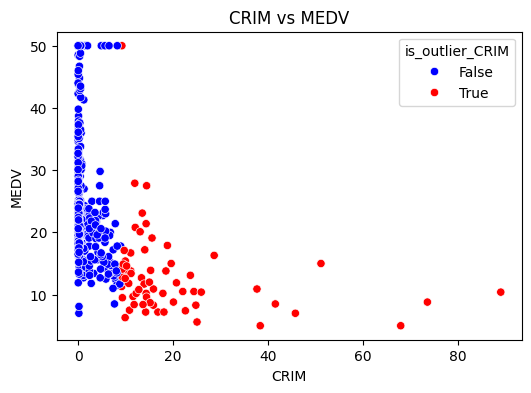

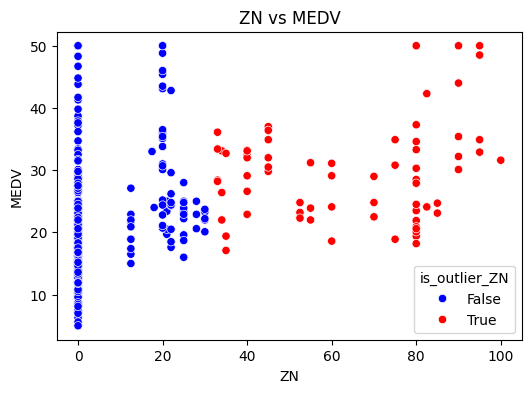

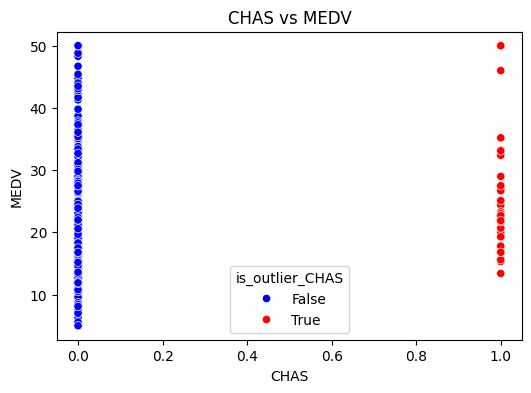

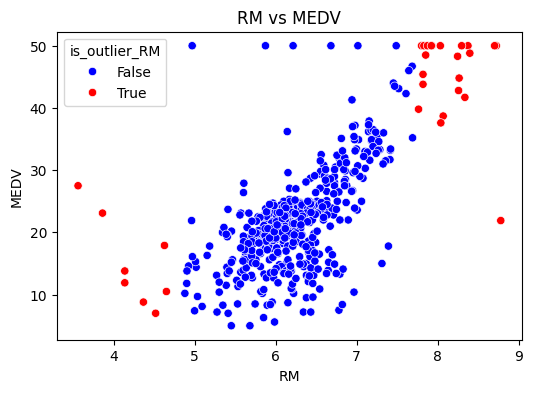

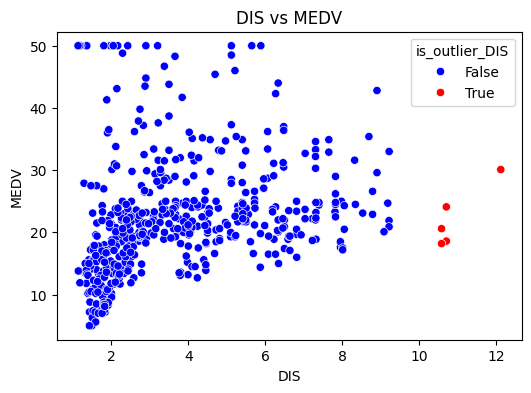

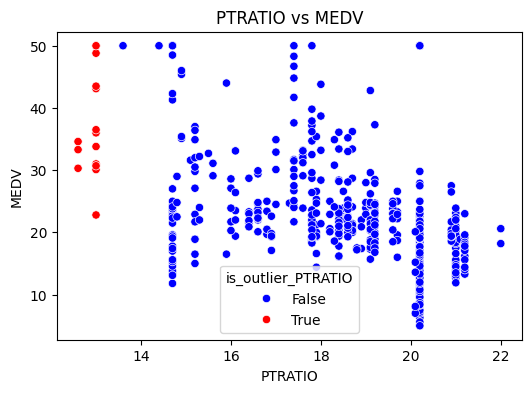

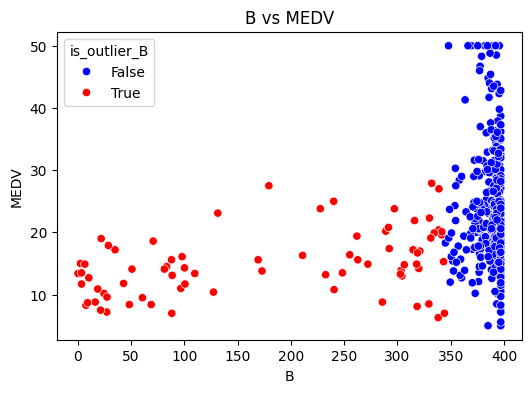

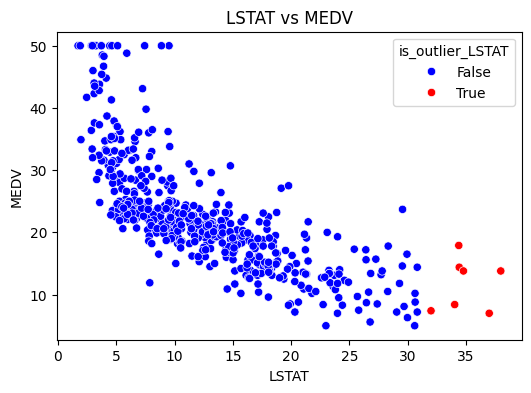

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variáveis que têm outliers (excluindo MEDV, se quiser)
vars_outliers = [col for col in numericas if df[f'is_outlier_{col}'].sum() > 0 and col != 'MEDV']

for var in vars_outliers:
    plt.figure(figsize=(6,4))
    sns.scatterplot(
        x=df[var],
        y=df['MEDV'],
        hue=df[f'is_outlier_{var}'], 
        palette={False:'blue', True:'red'}
    )
    plt.title(f'{var} vs MEDV')
    plt.xlabel(var)
    plt.ylabel('MEDV')
    plt.show()

In [12]:
vars_outliers = [col for col in numericas if df[f'is_outlier_{col}'].sum() > 0]

# Para cada variável, mostrar os valores que são outliers junto com MEDV
for var in vars_outliers:
    outliers = df[df[f'is_outlier_{var}']]
    print(f"\nOutliers da variável {var}:")
    print(outliers[[var, 'MEDV']])
    print('-'*50)


Outliers da variável CRIM:
        CRIM  MEDV
367  13.5222  23.1
371   9.2323  50.0
373  11.1081  13.8
374  18.4982  13.8
375  19.6091  15.0
..       ...   ...
468  15.5757  19.1
469  13.0751  20.1
477  15.0234  12.0
478  10.2330  14.6
479  14.3337  21.4

[66 rows x 2 columns]
--------------------------------------------------

Outliers da variável ZN:
       ZN  MEDV
39   75.0  30.8
40   75.0  34.9
54   75.0  18.9
55   90.0  35.4
56   85.0  24.7
..    ...   ...
351  60.0  24.1
352  60.0  18.6
353  90.0  30.1
354  80.0  18.2
355  80.0  20.6

[68 rows x 2 columns]
--------------------------------------------------

Outliers da variável CHAS:
     CHAS  MEDV
142     1  13.4
152     1  15.3
154     1  17.0
155     1  15.6
160     1  27.0
162     1  50.0
163     1  50.0
208     1  24.4
209     1  20.0
210     1  21.7
211     1  19.3
212     1  22.4
216     1  23.3
218     1  21.5
219     1  23.0
220     1  26.7
221     1  21.7
222     1  27.5
234     1  29.0
236     1  25.1
269     1  20.